#### **Effect of Window Length on FFT of a Periodic Signal**

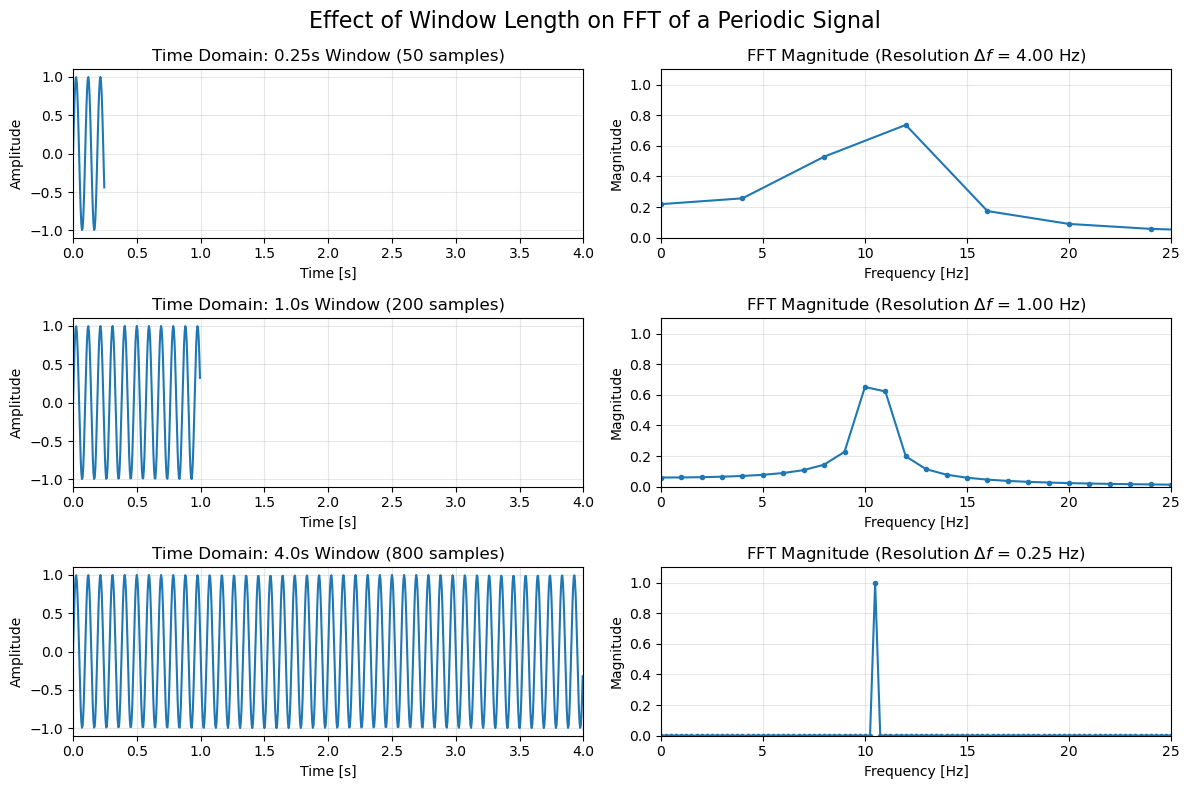

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def main():
    # 1. Define Signal Parameters
    fs = 200.0          # Sampling frequency (Hz)
    f0 = 10.5           # Signal frequency (Hz) - using 10.5 to show leakage intentionally
    
    # Define three different window lengths in seconds
    window_lengths = [0.25, 1.0, 4.0] 
    
    fig, axes = plt.subplots(len(window_lengths), 2, figsize=(12, 8))
    fig.suptitle('Effect of Window Length on FFT of a Periodic Signal', fontsize=16)

    for i, duration in enumerate(window_lengths):
        # Generate the time vector and signal for this specific window length
        t = np.arange(0, duration, 1/fs)
        N = len(t)
        
        # Create the signal: a simple sine wave
        # Using a rectangular window (default truncation)
        y = np.sin(2 * np.pi * f0 * t)
        
        # 2. Compute the FFT
        # use standard FFT without applying a specific window function (like Hamming)
        # to clearly see the effect of pure truncation (rectangular windowing)
        yf = fft(y)
        xf = fftfreq(N, 1/fs)[:N//2]
        
        # Calculate magnitude (normalized by N)
        magnitude = 2.0/N * np.abs(yf[0:N//2])

        # 3. Plot Time Domain
        ax_time = axes[i, 0]
        ax_time.plot(t, y)
        ax_time.set_title(f'Time Domain: {duration}s Window ({N} samples)')
        ax_time.set_xlabel('Time [s]')
        ax_time.set_ylabel('Amplitude')
        ax_time.set_xlim(0, max(window_lengths)) # Keep x-axis consistent for comparison
        ax_time.grid(True, alpha=0.3)

        # 4. Plot Frequency Domain
        ax_freq = axes[i, 1]
        ax_freq.plot(xf, magnitude, marker='o', markersize=3)
        ax_freq.set_title(f'FFT Magnitude (Resolution $\Delta f$ = {fs/N:.2f} Hz)')
        ax_freq.set_xlabel('Frequency [Hz]')
        ax_freq.set_ylabel('Magnitude')
        ax_freq.set_xlim(0, 25) # Zoom in around our 10.5 Hz signal
        ax_freq.set_ylim(0, 1.1)
        ax_freq.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()